# Daily diagnostics for the ten thesis assets

Visual and statistical diagnostics on the daily series used as input for QRF / QGB / GAS / GARCH-t / HISTSIM / EVT. Designed to fit on **one or two pages** of the Data section.

Four outputs:

1. **Price levels** â€” a 5x2 grid of split-adjusted closing prices on a log scale. Gives a visual sense of secular trends and major drawdowns. Requires `data_daily/` from `DAILY.ipynb` (falls back to a placeholder if absent).
2. **Returns time series** â€” a 5x2 grid showing the full daily-return path per asset.
3. **Return distributions** â€” a 5x2 grid of histograms with a fitted-normal density overlay. The visual gap in the tails is the standard graphical evidence for the leptokurtosis of equity returns.
4. **Summary statistics + diagnostic tests** â€” per-asset table with mean / std / min / max / skewness / excess kurtosis, the Jarque-Bera normality test, and Ljung-Box(20) on both $r_t$ (serial correlation) and $r_t^2$ (ARCH effects / volatility clustering).

PNG figures and a CSV table are saved to `output/` for direct inclusion in the thesis.

> **TODO** (once `INTRADAY_TAQ.ipynb` finishes and `data_intraday/<TICKER>_realized.csv` exists for every asset): extend this notebook with realized-volatility diagnostics â€” RV time series, ACF of RV (long-memory), and realized-correlation with SPY. See the last cell.

## Setup

Data-path resolution: this notebook prefers the price-enriched files from `DAILY.ipynb` (which include `prc_adj`) but falls back to the existing returns-only `data/` if `data_daily/` is not present. So the notebook produces a meaningful subset even if you have not yet run `DAILY.ipynb`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera, skew, kurtosis, norm
from statsmodels.stats.diagnostic import acorr_ljungbox

from features import load_returns, DEFAULT_FILES

# Try (in order): data_daily here, data_daily one level up (when DAILY.ipynb is in
# the project root), then the existing data folder as a returns-only fallback.
CANDIDATES = [Path("data_daily"), Path("../data_daily"), Path("data")]
DATA_DIR   = next((p for p in CANDIDATES if p.exists()), Path("data"))
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

N_ROWS, N_COLS = 2, 5
print(f"Using DATA_DIR = {DATA_DIR.resolve()}")

Using DATA_DIR = C:\Users\Kevin\OneDrive\Public\Documents\Scriptie\data_daily


## 1. Load the daily series for all ten assets

We read the *full* CSV (not only the returns columns) so that the price-plot in Section 2 can use `prc_adj` when available.

In [2]:
def _load_full(path):
    """Load the full CSV. Always parses DlyCalDt and DlyRet; passes through
    any extra columns (prc_adj, tri, prc_raw, openprc, vol) untouched."""
    df = pd.read_csv(path, sep=";")
    df["DlyCalDt"] = pd.to_datetime(df["DlyCalDt"], dayfirst=True)
    df["DlyRet"]   = pd.to_numeric(df["DlyRet"], errors="coerce")
    df = df.dropna(subset=["DlyCalDt", "DlyRet"])
    return df.sort_values("DlyCalDt").reset_index(drop=True)


returns = {}
for f in DEFAULT_FILES:
    name = f.replace(".csv", "")
    returns[name] = _load_full(DATA_DIR / f)

has_prices = all("prc_adj" in df.columns for df in returns.values())
print(f"Loaded {len(returns)} assets. prc_adj available: {has_prices}")
for name, df in returns.items():
    extra = [c for c in ("prc_adj", "tri") if c in df.columns]
    print(f"  {name:18s}  n = {len(df):5d}  "
          f"from {df['DlyCalDt'].min().date()} to {df['DlyCalDt'].max().date()}"
          + (f"   (extras: {', '.join(extra)})" if extra else ""))

Loaded 10 assets. prc_adj available: True
  MICROSOFT           n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  ASML                n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  CITIGROUP           n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  GENERALDYNAMICS     n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  JPM                 n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  NVIDIA              n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  PEPSICO             n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  QQQ                 n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  SPY                 n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)
  DIAGEO              n =  6289  from 2000-01-03 to 2024-12-31   (extras: prc_adj, tri)


## 2. Price levels (Figure 1 of the Data section)

5x2 grid of **split-adjusted closing prices** on a *log* scale. Log axis lets stocks at very different price levels (NVIDIA at $\sim$\$500 vs PEP at $\sim$\$150) share a comparable visual slope: equal vertical distance corresponds to equal percentage change. Major drawdowns (March 2020 COVID, 2022 tech sell-off, March 2023 regional-bank stress) appear as clear V-shapes across the cross-section.

This cell is skipped silently if `prc_adj` is unavailable (i.e. if `DAILY.ipynb` has not been run yet).

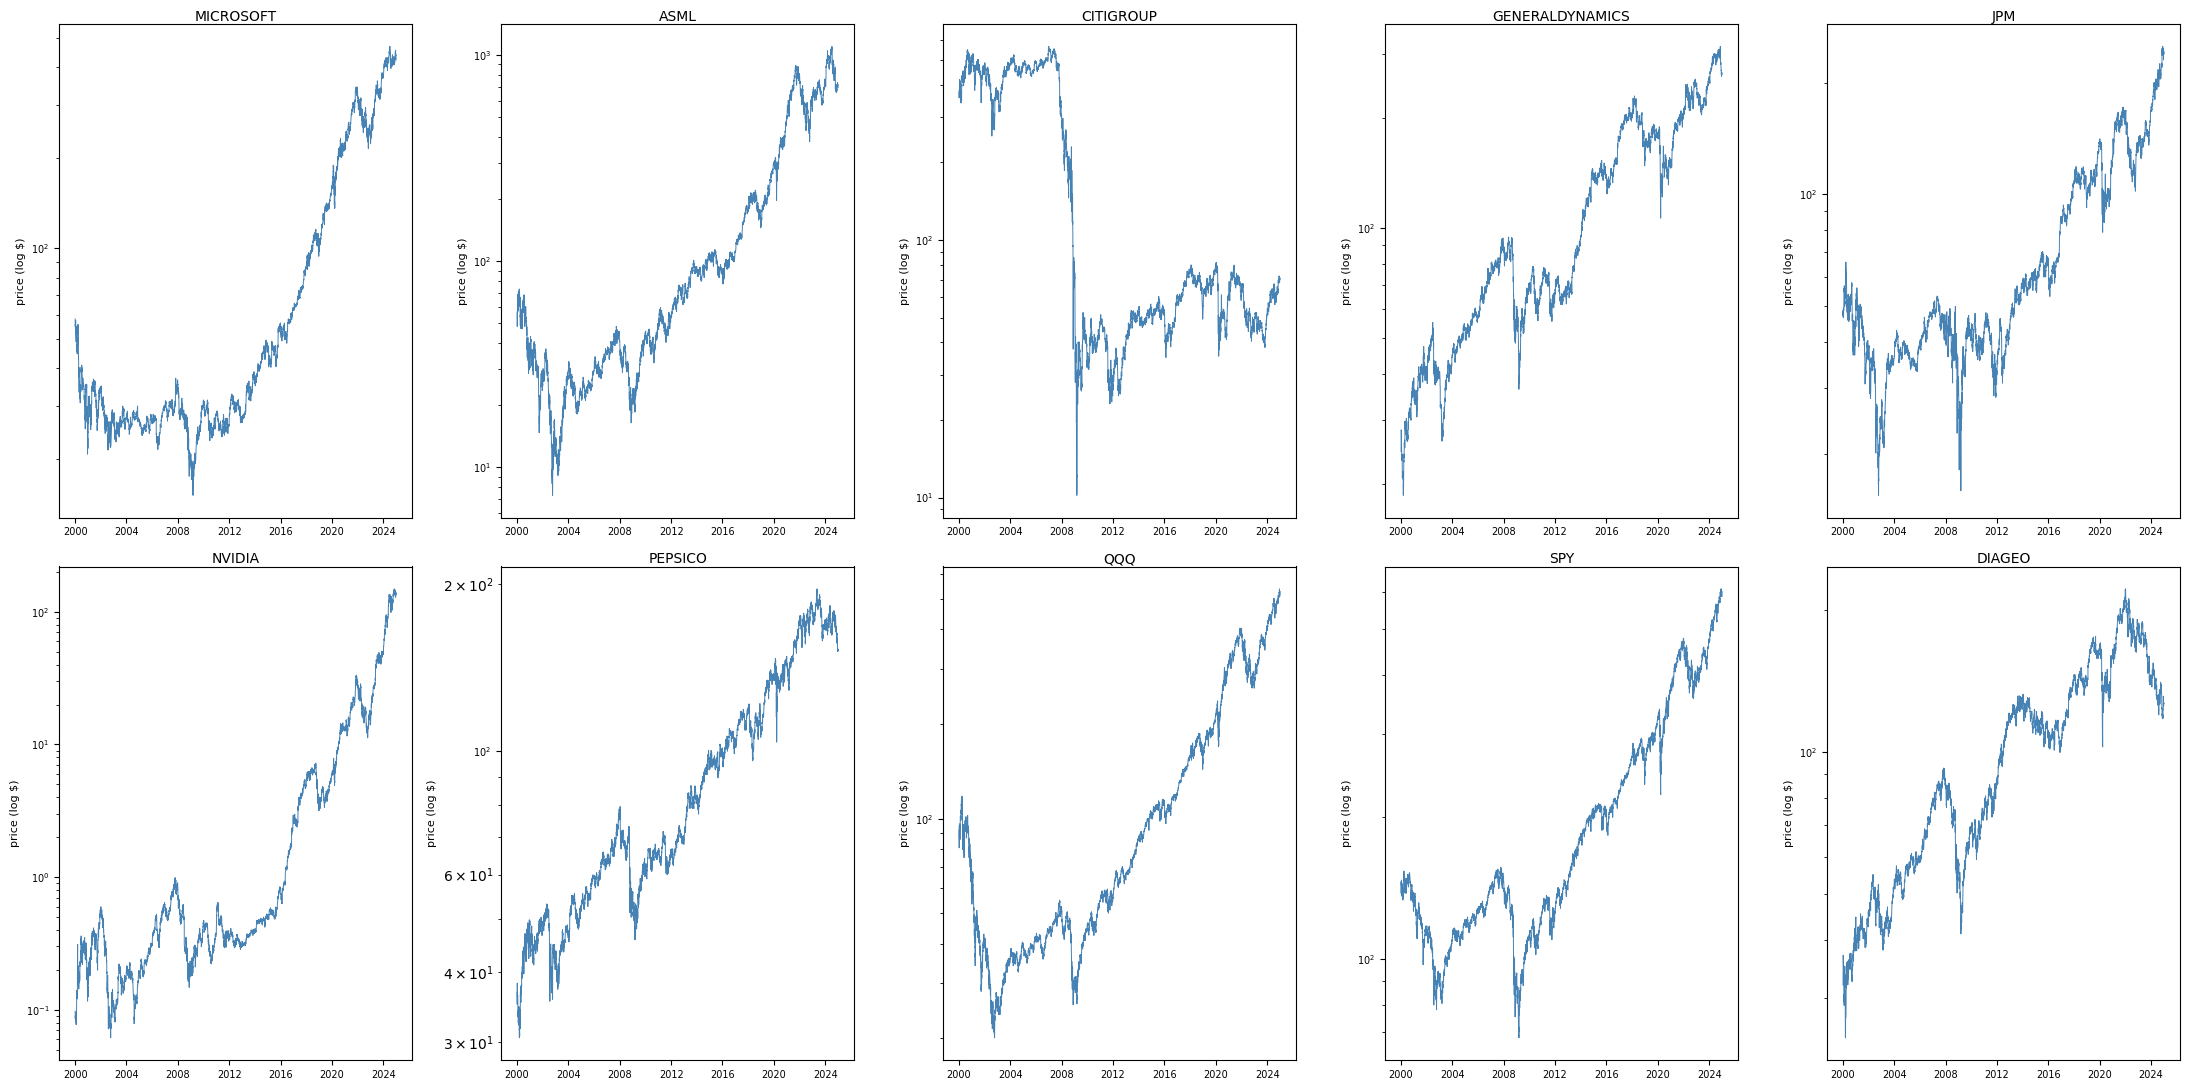

Saved -> output\diagnostics_prices_grid.png


In [3]:
if not has_prices:
    print("Skipping price grid: prc_adj column missing. Run DAILY.ipynb to populate data_daily/.")
else:
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(22, 11), sharex=False)
    for ax, (name, df) in zip(axes.flat, returns.items()):
        ax.plot(df["DlyCalDt"], df["prc_adj"], lw=0.7, color="steelblue")
        ax.set_yscale("log")
        ax.set_title(name, fontsize=10, pad=2)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylabel("price (log $)", fontsize=8)
    plt.tight_layout()
    out_path = OUTPUT_DIR / "diagnostics_prices_grid.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

## 3. Returns time series (Figure 2 of the Data section)

Compact 5x2 grid. Each panel: full daily-return path of one asset, $y$-axis fixed at $\pm 22\%$ for cross-sectional comparability.

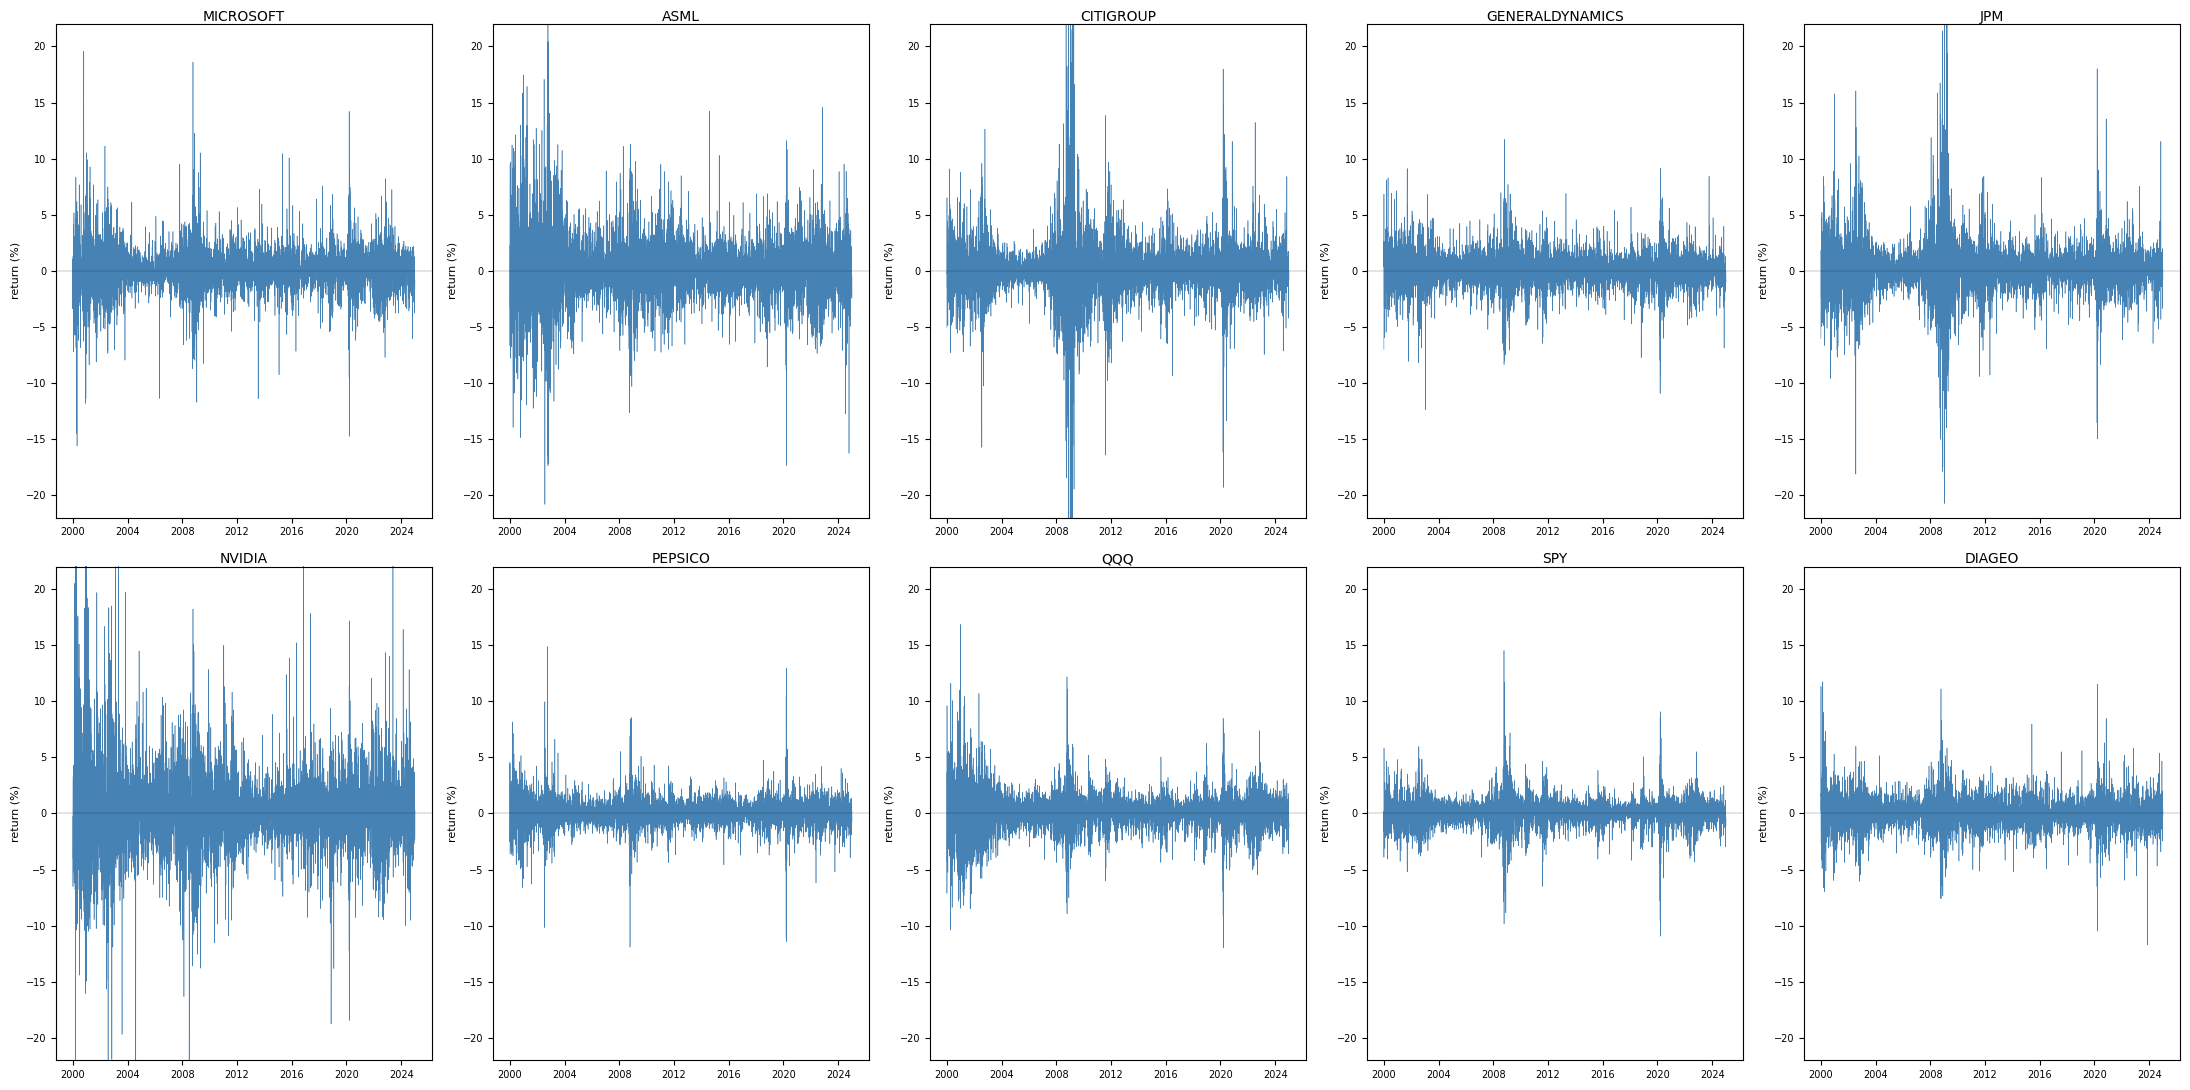

Saved -> output\diagnostics_returns_grid.png


In [4]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(22, 11), sharex=False)

for ax, (name, df) in zip(axes.flat, returns.items()):
    ax.plot(df["DlyCalDt"], df["DlyRet"] * 100, lw=0.4, color="steelblue")
    ax.axhline(0, color="k", lw=0.3, alpha=0.5)
    ax.set_title(name, fontsize=10, pad=2)
    ax.set_ylim(-22, 22)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_ylabel("return (%)", fontsize=8)

plt.tight_layout()
out_path = OUTPUT_DIR / "diagnostics_returns_grid.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_path}")

## 4. Return distributions with normal overlay (Figure 3 of the Data section)

5x2 grid of histograms (steel-blue bars) with a fitted-normal density overlay (red dashed). The visual gap between the histogram and the normal curve in the tails is the standard graphical motivation for heavy-tailed innovation models (Student-$t$ GARCH, EVT).

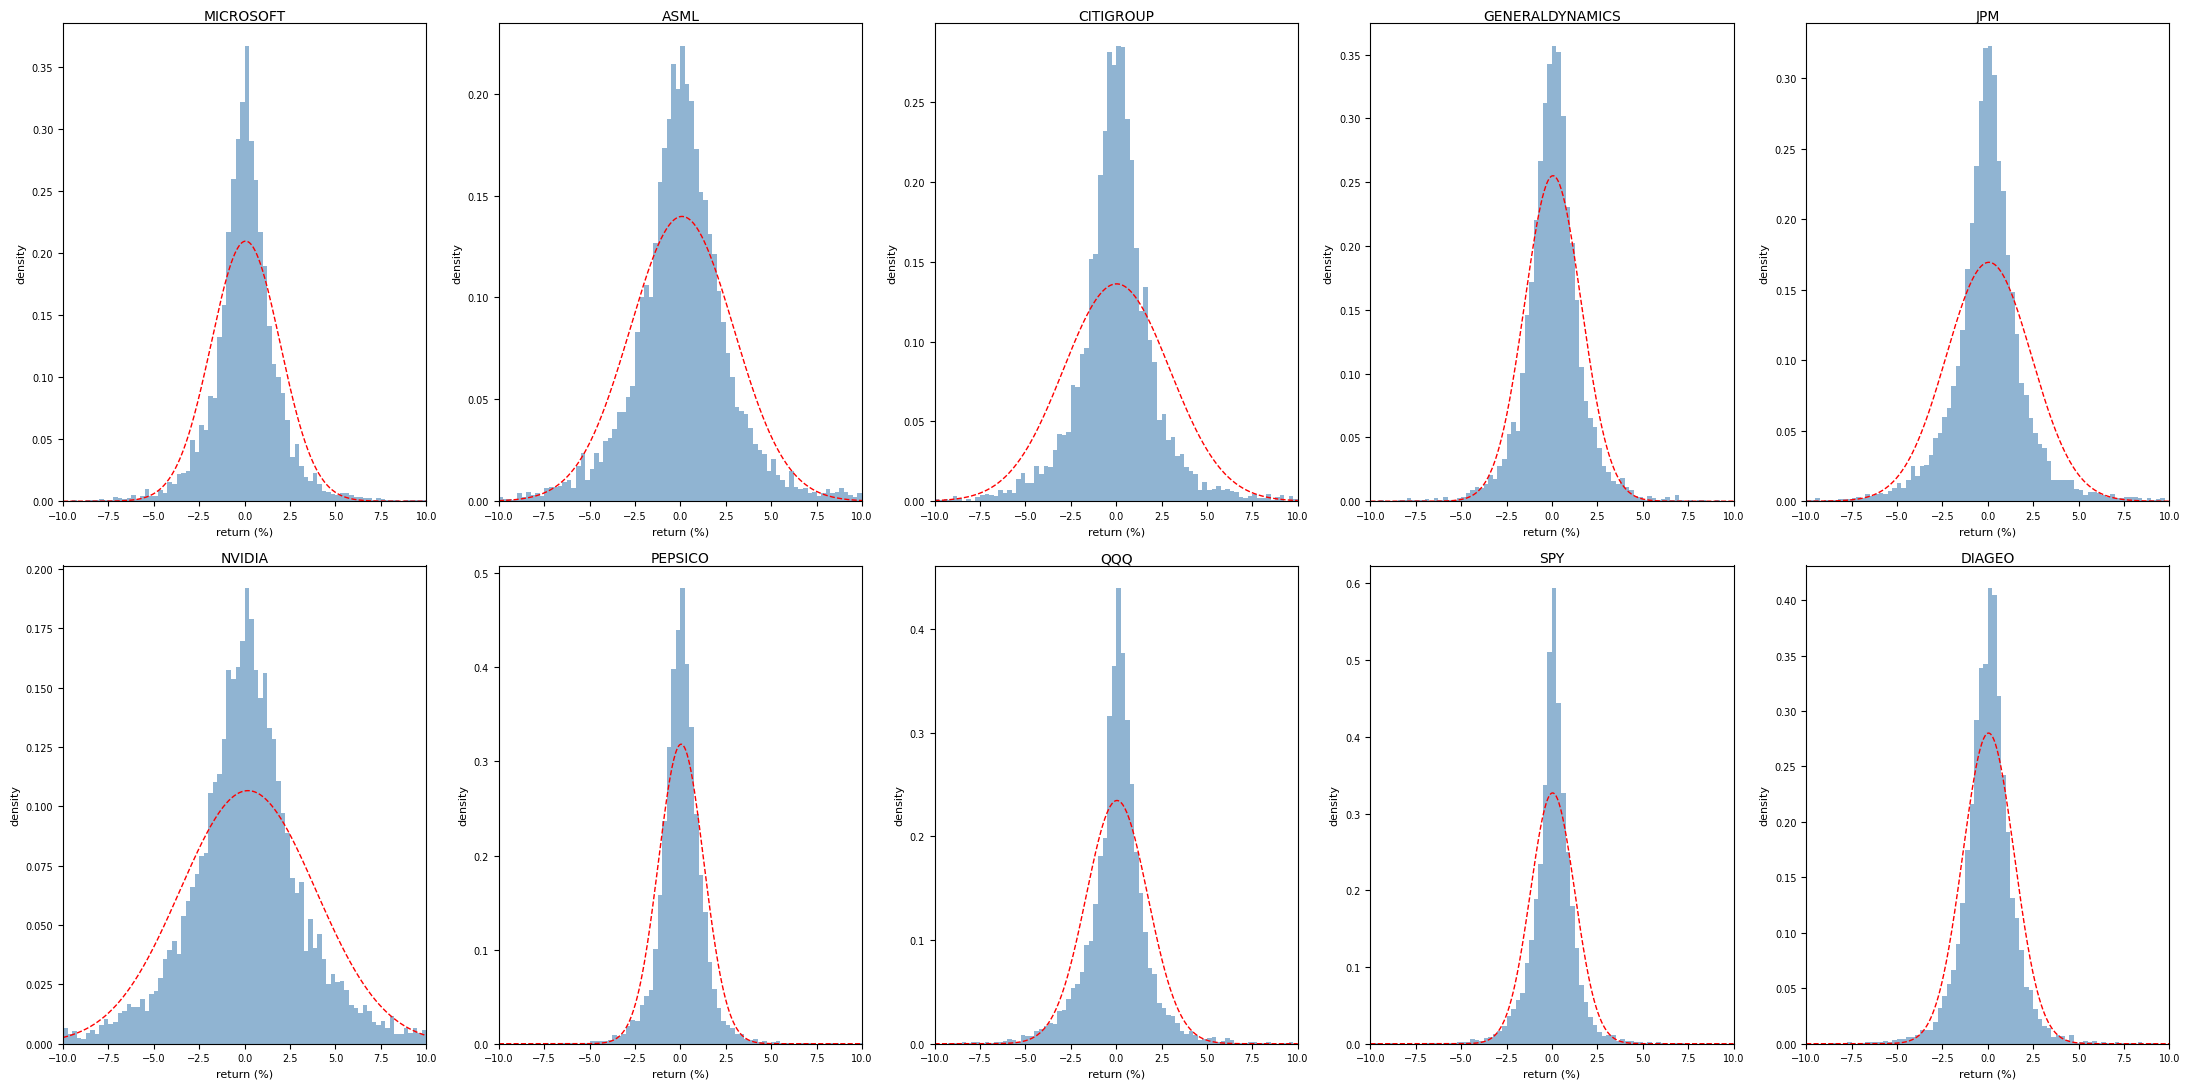

Saved -> output\diagnostics_distributions_grid.png


In [5]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(22, 11))

x_lo, x_hi = -10, 10  # percent
for ax, (name, df) in zip(axes.flat, returns.items()):
    r = df["DlyRet"].dropna().values * 100
    mu, sd = float(np.mean(r)), float(np.std(r, ddof=1))

    ax.hist(r, bins=80, range=(x_lo, x_hi), density=True,
            color="steelblue", alpha=0.6, edgecolor="none")

    xs = np.linspace(x_lo, x_hi, 400)
    ax.plot(xs, norm.pdf(xs, loc=mu, scale=sd),
            color="red", lw=1.0, ls="--")

    ax.set_title(name, fontsize=10, pad=2)
    ax.set_xlim(x_lo, x_hi)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_xlabel("return (%)", fontsize=8)
    ax.set_ylabel("density", fontsize=8)

plt.tight_layout()
out_path = OUTPUT_DIR / "diagnostics_distributions_grid.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_path}")

## 5. Summary statistics and diagnostic tests

Per-asset:

- **Mean, Std, Min, Max** (in %)
- **Skew, Excess Kurtosis** (normal $\Rightarrow 0$)
- **Jarque-Bera p-value** â€” normality test, almost universally rejected for equity returns
- **Ljung-Box(20) on $r_t$ p-value** â€” tests serial correlation in returns
- **Ljung-Box(20) on $r_t^2$ p-value** â€” tests autocorrelation in squared returns, the canonical diagnostic for ARCH effects / volatility clustering. Strong rejection is the standard empirical motivation for GARCH-type and score-driven models (Section 4.3)

A second cell renders the same table in LaTeX so it can be pasted directly into the thesis.

In [6]:
rows = []
for name, df in returns.items():
    r = df["DlyRet"].dropna().values

    mu  = float(np.mean(r)) * 100
    sd  = float(np.std(r, ddof=1)) * 100
    mn  = float(np.min(r)) * 100
    mx  = float(np.max(r)) * 100
    sk  = float(skew(r))
    kt  = float(kurtosis(r))  # excess kurtosis (normal = 0)

    jb_stat, jb_p = jarque_bera(r)

    lb_r  = acorr_ljungbox(r,      lags=[20], return_df=True).iloc[0]
    lb_r2 = acorr_ljungbox(r ** 2, lags=[20], return_df=True).iloc[0]

    rows.append({
        "stock":      name,
        "n":          int(len(r)),
        "mean (%)":   mu,
        "std (%)":    sd,
        "min (%)":    mn,
        "max (%)":    mx,
        "skew":       sk,
        "ex_kurt":    kt,
        "JB p":       float(jb_p),
        "LB20(r) p":  float(lb_r["lb_pvalue"]),
        "LB20(r2) p": float(lb_r2["lb_pvalue"]),
    })

stats_df = pd.DataFrame(rows).set_index("stock")
out_path = OUTPUT_DIR / "diagnostics_summary.csv"
stats_df.to_csv(out_path, sep=";", float_format="%.4f")
print(f"Saved -> {out_path}\n")

with pd.option_context("display.float_format", lambda x: f"{x:.3f}",
                       "display.width", 140):
    print(stats_df.to_string())

Saved -> output\diagnostics_summary.csv

                    n  mean (%)  std (%)  min (%)  max (%)   skew  ex_kurt  JB p  LB20(r) p  LB20(r2) p
stock                                                                                                  
MICROSOFT        6289     0.057    1.902  -15.598   19.565  0.167    9.536 0.000      0.000       0.000
ASML             6289     0.089    2.855  -20.806   22.121  0.133    5.519 0.000      0.000       0.000
CITIGROUP        6289     0.024    2.931  -39.024   57.825  1.374   48.968 0.000      0.000       0.000
GENERALDYNAMICS  6289     0.057    1.564  -12.377   11.728 -0.086    5.126 0.000      0.002       0.000
JPM              6289     0.063    2.355  -20.727   25.097  0.806   15.737 0.000      0.000       0.000
NVIDIA           6289     0.186    3.741  -35.233   42.414  0.585   12.070 0.000      0.000       0.000
PEPSICO          6289     0.041    1.253  -11.931   14.869  0.169   14.783 0.000      0.000       0.000
QQQ              6289  

In [7]:
# LaTeX rendering for direct paste into the thesis Data section.
latex = stats_df.to_latex(
    float_format="%.3f",
    caption=("Per-asset descriptive statistics and diagnostic tests on daily returns. "
             "Skew and excess kurtosis are zero under normality. JB is the Jarque-Bera "
             "normality test; LB20(r) and LB20(r$^2$) are Ljung-Box statistics at lag 20 "
             "on the returns and squared returns respectively. P-values below."),
    label="tab:daily-diagnostics",
    position="h",
)
print(latex)

\begin{table}[h]
\caption{Per-asset descriptive statistics and diagnostic tests on daily returns. Skew and excess kurtosis are zero under normality. JB is the Jarque-Bera normality test; LB20(r) and LB20(r$^2$) are Ljung-Box statistics at lag 20 on the returns and squared returns respectively. P-values below.}
\label{tab:daily-diagnostics}
\begin{tabular}{lrrrrrrrrrr}
\toprule
 & n & mean (%) & std (%) & min (%) & max (%) & skew & ex_kurt & JB p & LB20(r) p & LB20(r2) p \\
stock &  &  &  &  &  &  &  &  &  &  \\
\midrule
MICROSOFT & 6289 & 0.057 & 1.902 & -15.598 & 19.565 & 0.167 & 9.536 & 0.000 & 0.000 & 0.000 \\
ASML & 6289 & 0.089 & 2.855 & -20.806 & 22.121 & 0.133 & 5.519 & 0.000 & 0.000 & 0.000 \\
CITIGROUP & 6289 & 0.024 & 2.931 & -39.024 & 57.825 & 1.374 & 48.968 & 0.000 & 0.000 & 0.000 \\
GENERALDYNAMICS & 6289 & 0.057 & 1.564 & -12.377 & 11.728 & -0.086 & 5.126 & 0.000 & 0.002 & 0.000 \\
JPM & 6289 & 0.063 & 2.355 & -20.727 & 25.097 & 0.806 & 15.737 & 0.000 & 0.000 & 0.000 \\
N

## 6. (TODO) Realized-measure extension

Once `INTRADAY_TAQ.ipynb` has produced `data_intraday/<TICKER>_realized.csv` for every asset, add the following plots here as Figure 4 of the Data section:

- **Annualised RV time series** â€” $\sqrt{252 \cdot \text{RV}_t}$ per asset on a 5x2 grid. Spikes around major events should be sharper than in the daily-return panels.
- **ACF of RV** â€” 5x2 grid of `plot_acf(RV)` with lags up to ~100. Equity RV has a well-documented long-memory pattern (slow polynomial decay), which is the empirical motivation for HAR-RV models and related approaches.
- **Realized correlation with SPY across yearly subsamples** â€” heatmap of $\mathrm{corr}(r^{5\text{min}}_t, r^{5\text{min}}_{\text{SPY},t})$ per asset per year. Visualises time variation in cross-sectional dependence.
- **$\sqrt{\text{RV}_t}$ versus the GARCH(1,1)-t $\sigma_t$** on the same time axis for one or two representative assets. Visual gauge of how well the parametric volatility model tracks the realised quantity (the standard diagnostic of the realized-GARCH literature).